In [1]:
import torch
import numpy as np
import random

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import sys
!{sys.executable} -m pip install torch "gluonts[torch]"

In [4]:
import pandas as pd
import numpy as np
from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.evaluation import make_evaluation_predictions, Evaluator
import statsmodels.formula.api as smf
import gc
import os

In [5]:
# load data
import os
import pandas as pd
os.chdir("/Users/conniezhang/Desktop/ECON491/data/")

# 1. Load BOTH your train and test datasets
sales_train = pd.read_csv("Sales Train Validation.csv")
sales_test = pd.read_csv("sales Test Validation.csv")

# Automatically find which ID columns exist in BOTH datasets so we don't get a KeyError
common_cols = [col for col in ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'] 
               if col in sales_train.columns and col in sales_test.columns]

print("Merging on these common columns:", common_cols)

if len(common_cols) > 0:
    # Combine them together
    sales_combined = pd.merge(sales_train, sales_test, on=common_cols, how='left')
    sales_train = sales_combined
else:
    print("WARNING: No common ID columns found to merge on! Check your test file.")

calendar = pd.read_csv("Calendar (1).csv")
prices = pd.read_csv("sell_prices.csv")


Merging on these common columns: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']


In [6]:
# process the sales data

# Drop unused columns to save RAM immediately
sales_train = sales_train.drop(columns=["cat_id", "state_id"])

# Find all the day columns (d_1, d_2, etc.)
day_cols = [col for col in sales_train.columns if col.startswith('d_')]

# Melt the dataframe (equivalent to your long_sales in R)
long_sales = pd.melt(
    sales_train, 
    id_vars=['item_id', 'dept_id', 'store_id'], 
    value_vars=day_cols, 
    var_name='d', 
    value_name='sales'
)

# Clear old wide data from RAM
del sales_train
gc.collect()

80

In [7]:
# prepare calendar data and join
calendar['d'] = 'd_' + (calendar.index + 1).astype(str)

# Keep only what we need
slim_calendar = calendar[['d', 'date', 'wm_yr_wk', 'wday', 'month', 'event_type_1']].copy()
slim_calendar['date'] = pd.to_datetime(slim_calendar['date'])

# Merge sales and calendar (like your on="d" join)
final_df = pd.merge(long_sales, slim_calendar, on='d', how='left')

del long_sales, slim_calendar
gc.collect()

0

In [8]:
# 1. Define the split date (must be BEFORE computing weights)
split_date = pd.to_datetime("2016-04-24")

# 2. Use ONLY training-period data to compute item weights
train_final_df = final_df[final_df['date'] <= split_date].copy()

item_weights = train_final_df.groupby(['item_id', 'store_id', 'dept_id'])['sales'].sum().reset_index(name='item_lifetime_sales')

# 3. Merge prices with these *historical-only* weights
prices_mapped = pd.merge(prices, item_weights, on=['item_id', 'store_id'])

# 4. Calculate weighted average price (no future information now)
prices_mapped['weighted_price'] = prices_mapped['sell_price'] * prices_mapped['item_lifetime_sales']
dept_prices = prices_mapped.groupby(['store_id', 'dept_id', 'wm_yr_wk']).apply(
    lambda x: x['weighted_price'].sum() / x['item_lifetime_sales'].sum()
).reset_index(name='avg_price')

# 5. Clean up
del prices_mapped, item_weights, train_final_df
gc.collect()

0

In [9]:
# assemble model data
# Aggregate daily sales to store-dept level
model_data = final_df.groupby(['store_id', 'dept_id', 'date', 'wm_yr_wk', 'wday', 'month', 'event_type_1'], dropna=False)['sales'].sum().reset_index(name='total_sales')

# Join prices
model_data = pd.merge(model_data, dept_prices, on=['store_id', 'dept_id', 'wm_yr_wk'], how='left')

# Drop rows with missing prices
model_data = model_data.dropna(subset=['avg_price'])

# Create Dummy Variables for the Econometrics Model
model_data['day_of_week'] = model_data['wday'].astype(str) # Treat as categorical
model_data['month_factor'] = model_data['month'].astype(str) # Treat as categorical
model_data['is_holiday'] = np.where(model_data['event_type_1'].isna(), 0, 1) # 1 if event, 0 if normal

In [10]:
# train/test split
split_date = pd.to_datetime("2016-04-24")
train_data = model_data[model_data['date'] <= split_date]
test_data = model_data[model_data['date'] > split_date].copy()

In [11]:
# run the simple benchmark model
# In Python's statsmodels, 'C()' tells it to treat a variable as a categorical factor (dummy variable)
formula = "total_sales ~ avg_price + C(day_of_week) + C(month_factor) + is_holiday"

# Fit the model
simple_model = smf.ols(formula=formula, data=train_data).fit()

# Print the beautiful Econometrics summary table!
print(simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_sales   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     984.3
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:30:09   Log-Likelihood:            -1.0384e+06
No. Observations:              133910   AIC:                         2.077e+06
Df Residuals:                  133890   BIC:                         2.077e+06
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1263.42

In [12]:
# reshaping data for deepAR
ts_data = model_data.pivot_table(
    index='date', 
    columns=['store_id', 'dept_id'], 
    values='total_sales', 
    aggfunc='sum'
)

# 1. Convert to datetime
ts_data.index = pd.to_datetime(ts_data.index)

# 2. Force daily frequency (this creates rows with NaNs for missing days)
ts_data = ts_data.asfreq('D')

# 3. THE FIX: Fill missing days with 0, but ONLY after the first recorded sale
# (Leaves pre-launch days as NaN so the model knows the product didn't exist yet)
for col in ts_data.columns:
    first_valid_date = ts_data[col].first_valid_index()
    if first_valid_date is not None:
        ts_data.loc[first_valid_date:, col] = ts_data.loc[first_valid_date:, col].fillna(0)

# Preview the data
ts_data.iloc[:5, :4]

store_id      CA_1                          
dept_id    FOODS_1 FOODS_2 FOODS_3 HOBBIES_1
date                                        
2011-01-29     297     674    2268       528
2011-01-30     284     655    2198       489
2011-01-31     214     396    1398       409
2011-02-01     175     476    1607       383
2011-02-02     182     354    1496       263

In [13]:
# 1. Get a list of all unique departments from your pivot table
departments = ts_data.columns.get_level_values('dept_id').unique()

# 2. Create dictionaries to store your trained models and datasets
trained_predictors = {}
test_datasets = {}

prediction_length = 27
split_date = pd.to_datetime("2016-04-24")

# 3. Loop through each department and train a separate model
for dept in departments:
    print(f"--- Preparing and Training Model for Department: {dept} ---")
    
    # Isolate the data just for this department across all stores
    # .xs grabs a "cross-section" of your MultiIndex columns
    dept_ts_data = ts_data.xs(dept, level='dept_id', axis=1)
    
    # Split train/test for this specific department
    train_dept_ts = dept_ts_data[dept_ts_data.index <= split_date]
    test_dept_ts = dept_ts_data
    
    # Create GluonTS Datasets
    train_ds = ListDataset(
        [{"start": train_dept_ts.index[0], "target": train_dept_ts[col].values} for col in train_dept_ts.columns],
        freq="D"
    )
    
    test_ds = ListDataset(
        [{"start": test_dept_ts.index[0], "target": test_dept_ts[col].values} for col in test_dept_ts.columns],
        freq="D"
    )
    
    # Initialize the DeepAR model for this department
    estimator = DeepAREstimator(
        freq="D",
        prediction_length=prediction_length,
        context_length=prediction_length * 2, 
        num_layers=2,
        hidden_size=32,
        trainer_kwargs={
            "max_epochs": 15,  # You might want to lower this so the loop doesn't take hours!
            "accelerator": "cpu",
            "enable_progress_bar": False
        } 
    )
    
    # Train the model
    predictor = estimator.train(train_ds)
    
    # Save the trained predictor and test dataset to our dictionaries
    trained_predictors[dept] = predictor
    test_datasets[dept] = test_ds

print("All Department Models Trained Successfully!")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 17.6 K | train | [[1, 1], [1, 1], [1, 1146, 4], [1, 1146], [1, 1146], [1, 27, 4]] | [1, 100, 27]
--------------------------------------------------------------------------------------------------------------------------------
17.6 K    Trainable params
0         Non-trainable params
17.6 K    Total params
0.071     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


--- Preparing and Training Model for Department: FOODS_1 ---


Epoch 0, global step 50: 'train_loss' reached 6.22295 (best 6.22295), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_204/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.48070 (best 5.48070), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_204/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.42828 (best 5.42828), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_204/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.33496 (best 5.33496), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_204/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.30073 (best 5.30073), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_204/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5

--- Preparing and Training Model for Department: FOODS_2 ---


Epoch 0, global step 50: 'train_loss' reached 6.41658 (best 6.41658), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_205/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.87139 (best 5.87139), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_205/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.69620 (best 5.69620), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_205/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.57545 (best 5.57545), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_205/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.53230 (best 5.53230), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_205/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5

...

--- Preparing and Training Model for Department: HOUSEHOLD_1 ---


Epoch 0, global step 50: 'train_loss' reached 7.26240 (best 7.26240), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_209/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 6.18629 (best 6.18629), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_209/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.86566 (best 5.86566), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_209/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.79372 (best 5.79372), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_209/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.73010 (best 5.73010), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_209/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5

--- Preparing and Training Model for Department: HOUSEHOLD_2 ---


Epoch 0, global step 50: 'train_loss' reached 5.71450 (best 5.71450), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_210/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 4.86005 (best 4.86005), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_210/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 4.62805 (best 4.62805), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_210/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 4.51489 (best 4.51489), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_210/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 4.48742 (best 4.48742), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_210/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5

All Department Models Trained Successfully!


In [14]:
# Create variables to help us calculate the overall average later
total_mape = 0
total_rmse = 0
num_departments = len(trained_predictors)

print("--- Department Evaluation Report ---")

# Loop through every department we trained
for dept in trained_predictors.keys():
    
    # 1. Grab the specific model and test data for THIS department
    current_predictor = trained_predictors[dept]
    current_test_ds = test_datasets[dept]
    
    # 2. This is YOUR exact code, just using the current department's data!
    forecast_it, ts_it = make_evaluation_predictions(
        dataset=current_test_ds,  
        predictor=current_predictor,  
        num_samples=100,  
    )
    
    forecasts = list(forecast_it)
    tss = list(ts_it)
    
    evaluator = Evaluator(quantiles=[0.5]) 
    agg_metrics, item_metrics = evaluator(tss, forecasts)
    
    # 3. Print the results for this specific department
    print(f"Department {dept} | RMSE: {agg_metrics['RMSE']:.2f} | MAPE: {agg_metrics['MAPE'] * 100:.2f}%")
    
    # Add to our running totals
    total_mape += agg_metrics['MAPE'] * 100
    total_rmse += agg_metrics['RMSE']

# 4. Calculate and print the grand totals for your presentation!
print("-" * 40)
print(f"OVERALL AVERAGE RMSE: {total_rmse / num_departments:.2f}")
print(f"OVERALL AVERAGE MAPE: {total_mape / num_departments:.2f}%")
print("-" * 40)

--- Department Evaluation Report ---


Running evaluation: 10it [00:00, 93.77it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department FOODS_1 | RMSE: 86.73 | MAPE: 17.60%


Running evaluation: 10it [00:00, 120.06it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department FOODS_2 | RMSE: 96.45 | MAPE: 10.19%


...

Running evaluation: 10it [00:00, 115.96it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department HOUSEHOLD_1 | RMSE: 104.06 | MAPE: 9.34%


Running evaluation: 10it [00:00, 113.71it/s]


Department HOUSEHOLD_2 | RMSE: 35.81 | MAPE: 10.65%
----------------------------------------
OVERALL AVERAGE RMSE: 96.79
OVERALL AVERAGE MAPE: 13.73%
----------------------------------------


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [15]:
# 1. Pivot the price data
price_data = model_data.pivot_table(
    index='date', 
    columns=['store_id', 'dept_id'], 
    values='avg_price', 
    aggfunc='mean'
)

# 2. Convert to datetime
price_data.index = pd.to_datetime(price_data.index)

# 3. Force continuous daily calendar (this adds NaNs for days with no sales data)
price_data = price_data.asfreq('D')

# 4. NOW fill the missing values 
# 'ffill' carries yesterday's price forward for missing days. 
# The .fillna(0) catches any items that had no price on the very first day.
price_data = price_data.ffill().bfill()

In [16]:
# 1. Get a list of all unique departments from your pivot table
departments = ts_data.columns.get_level_values('dept_id').unique()

# 2. Create dictionaries to store your trained Econ models and datasets
trained_econ_predictors = {}
test_econ_datasets = {}

prediction_length = 27
split_date = pd.to_datetime("2016-04-24")

# 3. Loop through each department and train a separate Econ model
for dept in departments:
    print(f"--- Preparing and Training Econ Model for Department: {dept} ---")
    
    # Isolate SALES data for this department
    dept_ts_data = ts_data.xs(dept, level='dept_id', axis=1)
    train_dept_ts = dept_ts_data[dept_ts_data.index <= split_date]
    test_dept_ts = dept_ts_data
    
    # *** CHANGE 1: Isolate PRICE data for this department ***
    # (Assuming you already created 'price_data' from Cell 18)
    dept_price_data = price_data.xs(dept, level='dept_id', axis=1)
    train_dept_price = dept_price_data[dept_price_data.index <= split_date]
    test_dept_price = dept_price_data
    
    # *** CHANGE 2: Inject price into the Datasets ***
    train_ds_econ = ListDataset(
        [
            {
                "start": train_dept_ts.index[0], 
                "target": train_dept_ts[col].values,
                "feat_dynamic_real": [train_dept_price[col].values]
            } 
            for col in train_dept_ts.columns
        ],
        freq="D"
    )
    
    test_ds_econ = ListDataset(
        [
            {
                "start": test_dept_ts.index[0], 
                "target": test_dept_ts[col].values,
                "feat_dynamic_real": [test_dept_price[col].values]
            } 
            for col in test_dept_ts.columns
        ],
        freq="D"
    )
    
    # *** CHANGE 3: Update Estimator for dynamic features ***
    estimator_econ = DeepAREstimator(
        freq="D",
        prediction_length=prediction_length,
        context_length=prediction_length * 2, 
        num_feat_dynamic_real=1,  # <--- Telling the AI to expect the price data
        num_layers=2,
        hidden_size=32,
        trainer_kwargs={
            "max_epochs": 15, 
            "accelerator": "cpu",
            "enable_progress_bar": False
        } 
    )
    
    # Train the model
    predictor_econ = estimator_econ.train(train_ds_econ)
    
    # Save the trained predictor and test dataset
    trained_econ_predictors[dept] = predictor_econ
    test_econ_datasets[dept] = test_ds_econ

print("All Advanced Econ Department Models Trained Successfully!")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 17.8 K | train | [[1, 1], [1, 1], [1, 1146, 5], [1, 1146], [1, 1146], [1, 27, 5]] | [1, 100, 27]
--------------------------------------------------------------------------------------------------------------------------------
17.8 K    Trainable params
0         Non-trainable params
17.8 K    Total params
0.071     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


--- Preparing and Training Econ Model for Department: FOODS_1 ---


Epoch 0, global step 50: 'train_loss' reached 6.02655 (best 6.02655), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_211/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.45208 (best 5.45208), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_211/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.40481 (best 5.40481), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_211/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.31345 (best 5.31345), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_211/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.24344 (best 5.24344), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_211/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5

--- Preparing and Training Econ Model for Department: FOODS_2 ---


Epoch 0, global step 50: 'train_loss' reached 6.20101 (best 6.20101), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_212/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.83961 (best 5.83961), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_212/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.59023 (best 5.59023), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_212/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.51816 (best 5.51816), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_212/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.44424 (best 5.44424), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_212/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5

...

--- Preparing and Training Econ Model for Department: HOUSEHOLD_1 ---


Epoch 0, global step 50: 'train_loss' reached 7.04218 (best 7.04218), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_216/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 6.24059 (best 6.24059), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_216/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.94541 (best 5.94541), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_216/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.78414 (best 5.78414), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_216/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.75589 (best 5.75589), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_216/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5

--- Preparing and Training Econ Model for Department: HOUSEHOLD_2 ---


Epoch 0, global step 50: 'train_loss' reached 5.82290 (best 5.82290), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_217/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 4.87571 (best 4.87571), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_217/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 4.72672 (best 4.72672), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_217/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 4.57015 (best 4.57015), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_217/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 4.52605 (best 4.52605), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_217/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5

All Advanced Econ Department Models Trained Successfully!


In [17]:
# Create variables to track our overall averages for the Econ model
total_econ_mape = 0
total_econ_rmse = 0
num_departments = len(trained_econ_predictors)

print("--- Advanced (Econ) Department Evaluation Report ---")

# Loop through every Econ model we just trained
for dept in trained_econ_predictors.keys():
    
    # 1. Grab the specific Econ model and test data for THIS department
    current_predictor = trained_econ_predictors[dept]
    current_test_ds = test_econ_datasets[dept]
    
    # 2. Generate predictions
    forecast_it, ts_it = make_evaluation_predictions(
        dataset=current_test_ds,  
        predictor=current_predictor,  
        num_samples=100,  
    )
    
    forecasts = list(forecast_it)
    tss = list(ts_it)
    
    evaluator = Evaluator(quantiles=[0.5]) 
    agg_metrics, item_metrics = evaluator(tss, forecasts)
    
    # 3. Print the results for this specific department
    print(f"Department {dept} | Econ RMSE: {agg_metrics['RMSE']:.2f} | Econ MAPE: {agg_metrics['MAPE'] * 100:.2f}%")
    
    # Add to our running totals
    total_econ_mape += agg_metrics['MAPE'] * 100
    total_econ_rmse += agg_metrics['RMSE']

# 4. Calculate and print the grand totals!
print("-" * 40)
print(f"OVERALL ECON AVERAGE RMSE: {total_econ_rmse / num_departments:.2f}")
print(f"OVERALL ECON AVERAGE MAPE: {total_econ_mape / num_departments:.2f}%")
print("-" * 40)

--- Advanced (Econ) Department Evaluation Report ---


Running evaluation: 10it [00:00, 106.52it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department FOODS_1 | Econ RMSE: 83.78 | Econ MAPE: 16.39%


Running evaluation: 10it [00:00, 126.43it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department FOODS_2 | Econ RMSE: 100.22 | Econ MAPE: 10.57%


...

Running evaluation: 10it [00:00, 124.36it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department HOUSEHOLD_1 | Econ RMSE: 101.25 | Econ MAPE: 9.16%


Running evaluation: 10it [00:00, 129.09it/s]


Department HOUSEHOLD_2 | Econ RMSE: 34.54 | Econ MAPE: 10.16%
----------------------------------------
OVERALL ECON AVERAGE RMSE: 92.91
OVERALL ECON AVERAGE MAPE: 13.58%
----------------------------------------


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [18]:
from gluonts.evaluation import Evaluator

print("=" * 60)
print("FINAL OVERFITTING REPORT: TRAIN VS TEST".center(60))
print("=" * 60)

# Make sure we use the same split date as before
split_date = pd.to_datetime("2016-04-24")
evaluator = Evaluator(quantiles=[0.5])

for dept in departments:
    print(f"\n--- Analyzing Department: {dept} ---")
    
    # 1. Recreate the Training Data for this department (Base Model)
    dept_ts_data = ts_data.xs(dept, level='dept_id', axis=1)
    train_dept_ts = dept_ts_data[dept_ts_data.index <= split_date]
    train_ds_base = ListDataset(
        [{"start": train_dept_ts.index[0], "target": train_dept_ts[col].values} for col in train_dept_ts.columns],
        freq="D"
    )
    
    # 2. Recreate the Training Data for this department (Econ Model with Price)
    dept_price_data = price_data.xs(dept, level='dept_id', axis=1)
    train_dept_price = dept_price_data[dept_price_data.index <= split_date]
    train_ds_econ = ListDataset(
        [
            {
                "start": train_dept_ts.index[0], 
                "target": train_dept_ts[col].values,
                "feat_dynamic_real": [train_dept_price[col].values]
            } 
            for col in train_dept_ts.columns
        ],
        freq="D"
    )
    
    # --- EVALUATE BASE MODEL (TRAIN VS TEST) ---
    # Train
    fcst_train_base, ts_train_base = make_evaluation_predictions(dataset=train_ds_base, predictor=trained_predictors[dept], num_samples=100)
    metrics_train_base, _ = evaluator(list(ts_train_base), list(fcst_train_base))
    
    # Test (using the test datasets we saved earlier)
    fcst_test_base, ts_test_base = make_evaluation_predictions(dataset=test_datasets[dept], predictor=trained_predictors[dept], num_samples=100)
    metrics_test_base, _ = evaluator(list(ts_test_base), list(fcst_test_base))

    # --- EVALUATE ECON MODEL (TRAIN VS TEST) ---
    # Train
    fcst_train_econ, ts_train_econ = make_evaluation_predictions(dataset=train_ds_econ, predictor=trained_econ_predictors[dept], num_samples=100)
    metrics_train_econ, _ = evaluator(list(ts_train_econ), list(fcst_train_econ))
    
    # Test
    fcst_test_econ, ts_test_econ = make_evaluation_predictions(dataset=test_econ_datasets[dept], predictor=trained_econ_predictors[dept], num_samples=100)
    metrics_test_econ, _ = evaluator(list(ts_test_econ), list(fcst_test_econ))

    # --- PRINT THE RESULTS ---
    print("  [Base DeepAR]")
    print(f"    Train MAPE: {metrics_train_base['MAPE']*100:.2f}%  |  Test MAPE: {metrics_test_base['MAPE']*100:.2f}%")
    
    print("  [Advanced Econ DeepAR (w/ Price)]")
    print(f"    Train MAPE: {metrics_train_econ['MAPE']*100:.2f}%  |  Test MAPE: {metrics_test_econ['MAPE']*100:.2f}%")
    
print("\n" + "=" * 60)
print("REPORT COMPLETE")

          FINAL OVERFITTING REPORT: TRAIN VS TEST           

--- Analyzing Department: FOODS_1 ---


Running evaluation: 10it [00:00, 120.90it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 122.65it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 131.01it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 124.25it/s]
/opt/miniconda3/envs/econ491_walmart_forcas

  [Base DeepAR]
    Train MAPE: 16.17%  |  Test MAPE: 17.77%
  [Advanced Econ DeepAR (w/ Price)]
    Train MAPE: 17.80%  |  Test MAPE: 16.11%

--- Analyzing Department: FOODS_2 ---


Running evaluation: 10it [00:00, 102.20it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 125.28it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 129.19it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 134.74it/s]
/opt/miniconda3/envs/econ491_walmart_forcas

  [Base DeepAR]
    Train MAPE: 10.34%  |  Test MAPE: 10.16%
  [Advanced Econ DeepAR (w/ Price)]
    Train MAPE: 10.53%  |  Test MAPE: 10.52%

--- Analyzing Department: FOODS_3 ---


...

Running evaluation: 10it [00:00, 126.16it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 126.24it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 125.54it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 126.17it/s]
/opt/miniconda3/envs/econ491_walmart_forcas

  [Base DeepAR]
    Train MAPE: 8.45%  |  Test MAPE: 9.51%
  [Advanced Econ DeepAR (w/ Price)]
    Train MAPE: 7.95%  |  Test MAPE: 8.96%

--- Analyzing Department: HOUSEHOLD_2 ---


Running evaluation: 10it [00:00, 124.29it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 122.85it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 128.29it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 129.75it/s]


  [Base DeepAR]
    Train MAPE: 10.66%  |  Test MAPE: 10.28%
  [Advanced Econ DeepAR (w/ Price)]
    Train MAPE: 10.53%  |  Test MAPE: 9.91%

REPORT COMPLETE


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Generating plot for FOODS_1...


<Figure size 1200x600 with 0 Axes>

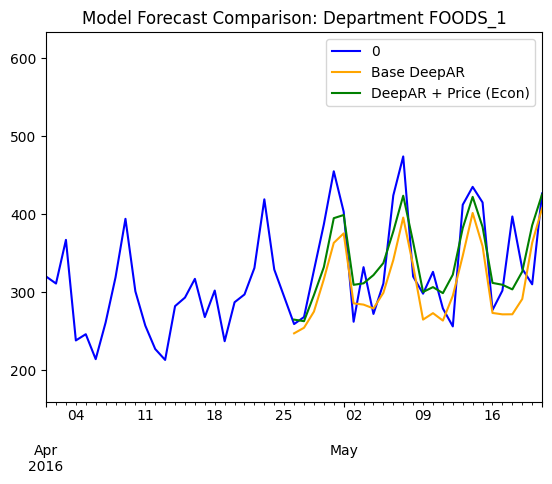

In [26]:
import matplotlib.pyplot as plt

# 1. Choose which department you want to visualize for your presentation
target_dept = "FOODS_1"  # Change this to 'HOBBIES_1', 'FOODS_2', etc., to see different charts!

print(f"Generating plot for {target_dept}...")

# 2. Grab predictions for the Base Model
forecast_it_base, ts_it_base = make_evaluation_predictions(
    dataset=test_datasets[target_dept],
    predictor=trained_predictors[target_dept],
    num_samples=100,
)
forecasts_base = list(forecast_it_base)
tss_base = list(ts_it_base)

# 3. Grab predictions for the Advanced (Econ) Model
forecast_it_econ, ts_it_econ = make_evaluation_predictions(
    dataset=test_econ_datasets[target_dept],
    predictor=trained_econ_predictors[target_dept],
    num_samples=100,
)
forecasts_econ = list(forecast_it_econ)

# 4. Extract the first store's time series from this specific department
ts = tss_base[0]
forecast_base = forecasts_base[0]
forecast_econ = forecasts_econ[0]

# 5. Plot the results!
plt.figure(figsize=(12,6))

# Actual values (looking at the last 100 days so we can see the forecast clearly)
ts[-100:].plot(color='blue', label="Actual Sales")
plt.xlim(pd.to_datetime('2016-04-01'), pd.to_datetime('2016-05-21'))

# Base model prediction (median)
plt.plot(forecast_base.index, forecast_base.quantile(0.5), color='orange', label="Base DeepAR")

# Econ model prediction (median)
plt.plot(forecast_econ.index, forecast_econ.quantile(0.5), color='green', label="DeepAR + Price (Econ)")

plt.title(f"Model Forecast Comparison: Department {target_dept}")
plt.legend()
plt.show()

Gathering metrics for the Bar Chart...


Running evaluation: 10it [00:00, 87.45it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 92.84it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 118.97it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 136.39it/s]
/opt/miniconda3/envs/econ491_walmart_forcasti

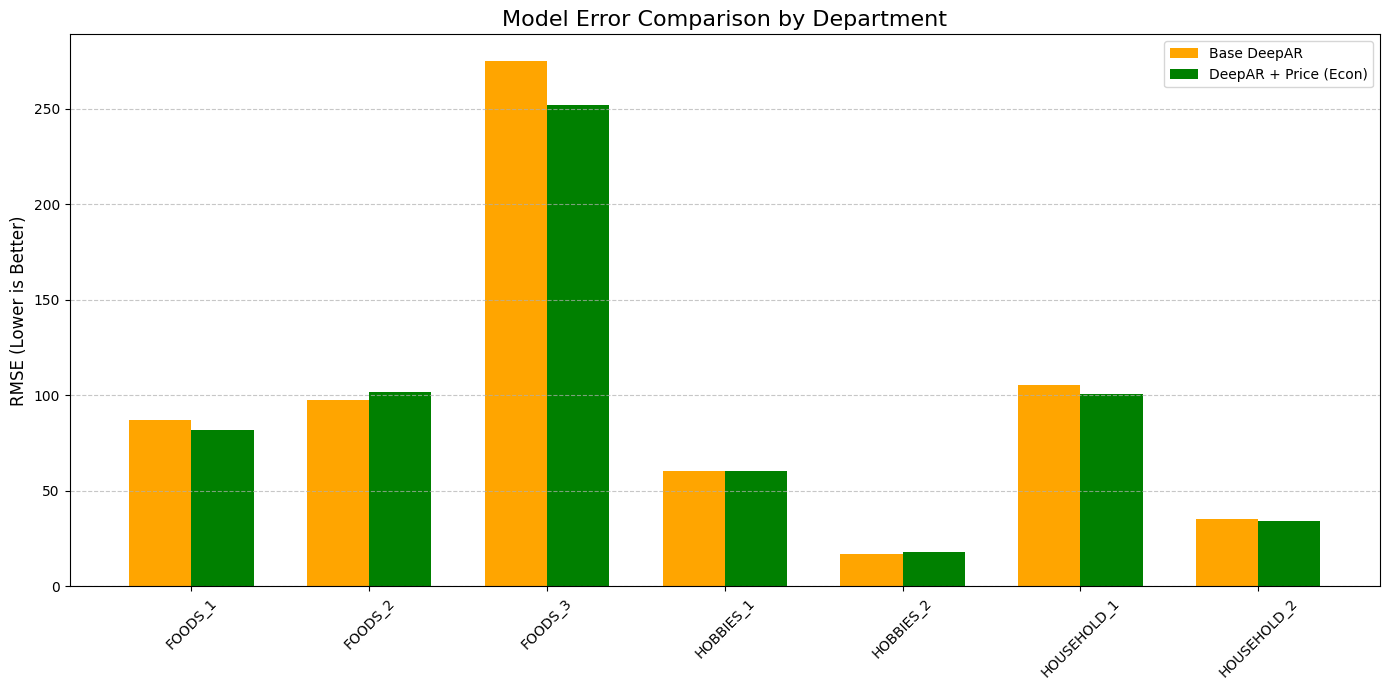

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from gluonts.evaluation import Evaluator

print("Gathering metrics for the Bar Chart...")
evaluator = Evaluator(quantiles=[0.5])
dept_names = list(departments)
base_rmse_list = []
econ_rmse_list = []

# Gather the data
for dept in dept_names:
    # Get Base RMSE
    fcst_base, ts_base = make_evaluation_predictions(dataset=test_datasets[dept], predictor=trained_predictors[dept], num_samples=100)
    metrics_base, _ = evaluator(list(ts_base), list(fcst_base))
    base_rmse_list.append(metrics_base['RMSE'])
    
    # Get Econ RMSE
    fcst_econ, ts_econ = make_evaluation_predictions(dataset=test_econ_datasets[dept], predictor=trained_econ_predictors[dept], num_samples=100)
    metrics_econ, _ = evaluator(list(ts_econ), list(fcst_econ))
    econ_rmse_list.append(metrics_econ['RMSE'])

# Create the Bar Chart
plt.figure(figsize=(14, 7))
x = np.arange(len(dept_names))
width = 0.35

plt.bar(x - width/2, base_rmse_list, width, label='Base DeepAR', color='orange')
plt.bar(x + width/2, econ_rmse_list, width, label='DeepAR + Price (Econ)', color='green')

plt.ylabel('RMSE (Lower is Better)', fontsize=12)
plt.title('Model Error Comparison by Department', fontsize=16)
plt.xticks(x, dept_names, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("rmse_comparison_bar_chart.png")
plt.show()

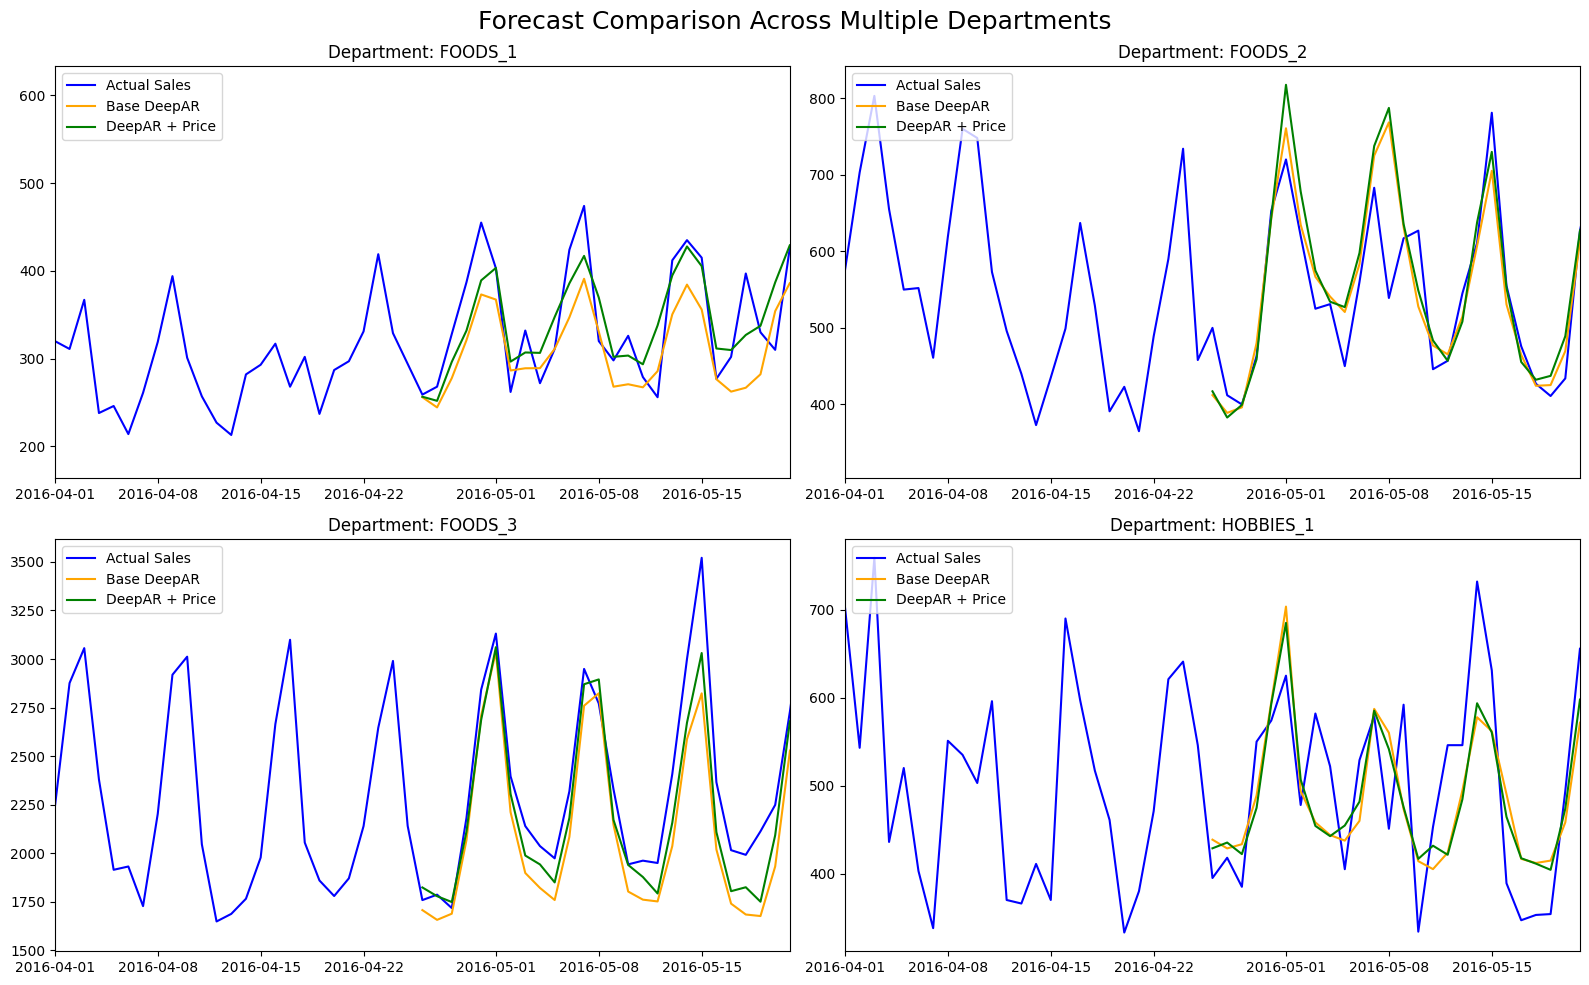

In [28]:
import matplotlib.pyplot as plt

# Pick any 4 departments you want to show off
target_depts = ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1'] 

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Forecast Comparison Across Multiple Departments', fontsize=18)

for idx, dept in enumerate(target_depts):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Get predictions
    fcst_it_base, ts_it_base = make_evaluation_predictions(dataset=test_datasets[dept], predictor=trained_predictors[dept], num_samples=100)
    fcst_it_econ, ts_it_econ = make_evaluation_predictions(dataset=test_econ_datasets[dept], predictor=trained_econ_predictors[dept], num_samples=100)
    
    ts = list(ts_it_base)[0]
    fcst_base = list(fcst_it_base)[0]
    fcst_econ = list(fcst_it_econ)[0]
    
    ax.plot(ts.index[-60:].to_timestamp(), ts.iloc[-60:, 0], color='blue', label="Actual Sales")
    ax.set_xlim(pd.to_datetime('2016-04-01'), pd.to_datetime('2016-05-21'))
    ax.plot(fcst_base.index.to_timestamp(), fcst_base.quantile(0.5), color='orange', label="Base DeepAR")
    ax.plot(fcst_econ.index.to_timestamp(), fcst_econ.quantile(0.5), color='green', label="DeepAR + Price")
    
    ax.set_title(f"Department: {dept}")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("4_department_grid_forecast.png")
plt.show()

Generating Total Store Forecast...


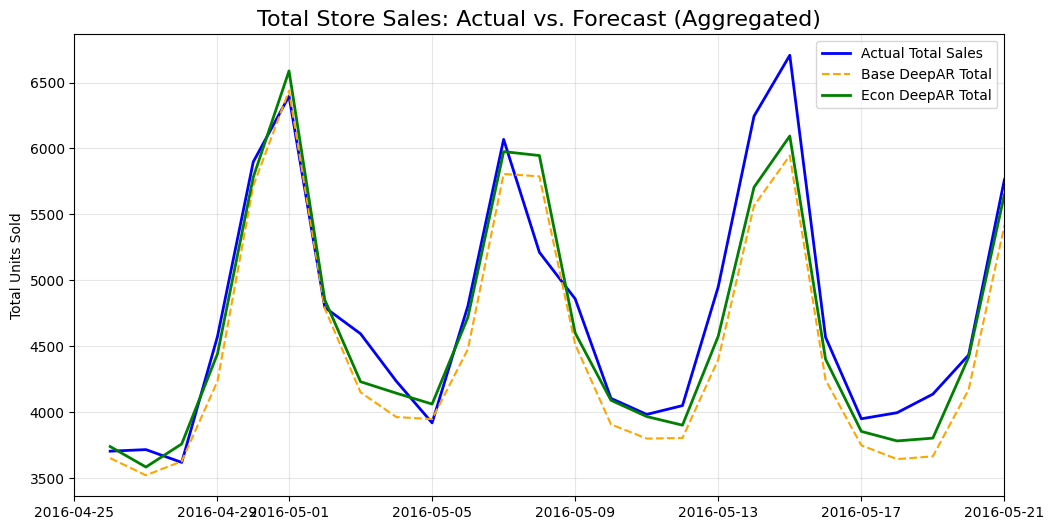

In [29]:
import matplotlib.pyplot as plt
import numpy as np

print("Generating Total Store Forecast...")

# 1. Aggregate Actuals and Predictions across all departments
total_actuals = 0
total_forecast_base = 0
total_forecast_econ = 0

for dept in trained_predictors.keys():
    # Base Predictions
    fcst_it_base, ts_it_base = make_evaluation_predictions(dataset=test_datasets[dept], predictor=trained_predictors[dept], num_samples=100)
    ts = list(ts_it_base)[0]
    fcst_base = list(fcst_it_base)[0]
    
    # Econ Predictions
    fcst_it_econ, ts_it_econ = make_evaluation_predictions(dataset=test_econ_datasets[dept], predictor=trained_econ_predictors[dept], num_samples=100)
    fcst_econ = list(fcst_it_econ)[0]
    
    # Add to totals
    if type(total_actuals) == int:
        total_actuals = ts.iloc[-27:, 0].values
        total_forecast_base = fcst_base.quantile(0.5)
        total_forecast_econ = fcst_econ.quantile(0.5)
    else:
        total_actuals += ts.iloc[-27:, 0].values
        total_forecast_base += fcst_base.quantile(0.5)
        total_forecast_econ += fcst_econ.quantile(0.5)

# 2. Plot the Total Store Sales
dates = fcst_base.index.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(dates, total_actuals, color='blue', label="Actual Total Sales", linewidth=2)
plt.xlim(pd.to_datetime('2016-04-25'), pd.to_datetime('2016-05-21'))
plt.plot(dates, total_forecast_base, color='orange', label="Base DeepAR Total", linestyle='--')
plt.plot(dates, total_forecast_econ, color='green', label="Econ DeepAR Total", linewidth=2)

plt.title("Total Store Sales: Actual vs. Forecast (Aggregated)", fontsize=16)
plt.ylabel("Total Units Sold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

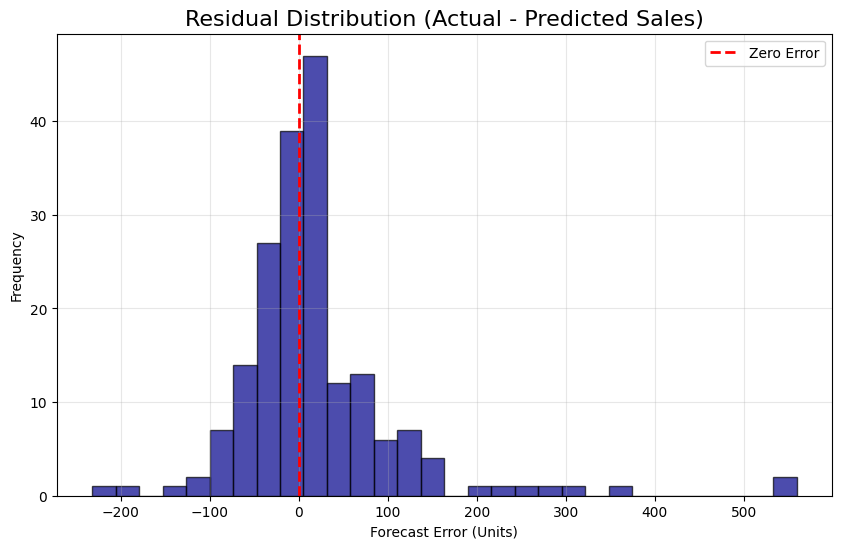

In [30]:
# Calculate errors (residuals) for the Econ Model across all departments
all_residuals = []

for dept in trained_econ_predictors.keys():
    fcst_it, ts_it = make_evaluation_predictions(dataset=test_econ_datasets[dept], predictor=trained_econ_predictors[dept], num_samples=100)
    ts = list(ts_it)[0].iloc[-27:, 0].values
    fcst = list(fcst_it)[0].quantile(0.5)
    
    residuals = ts - fcst
    all_residuals.extend(residuals)

# Plot the distribution of errors
plt.figure(figsize=(10, 6))
plt.hist(all_residuals, bins=30, color='darkblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='Zero Error')

plt.title("Residual Distribution (Actual - Predicted Sales)", fontsize=16)
plt.xlabel("Forecast Error (Units)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Running evaluation: 10it [00:00, 104.85it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 79.55it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 108.19it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 112.74it/s]
/opt/miniconda3/envs/econ491_walmart_forcast

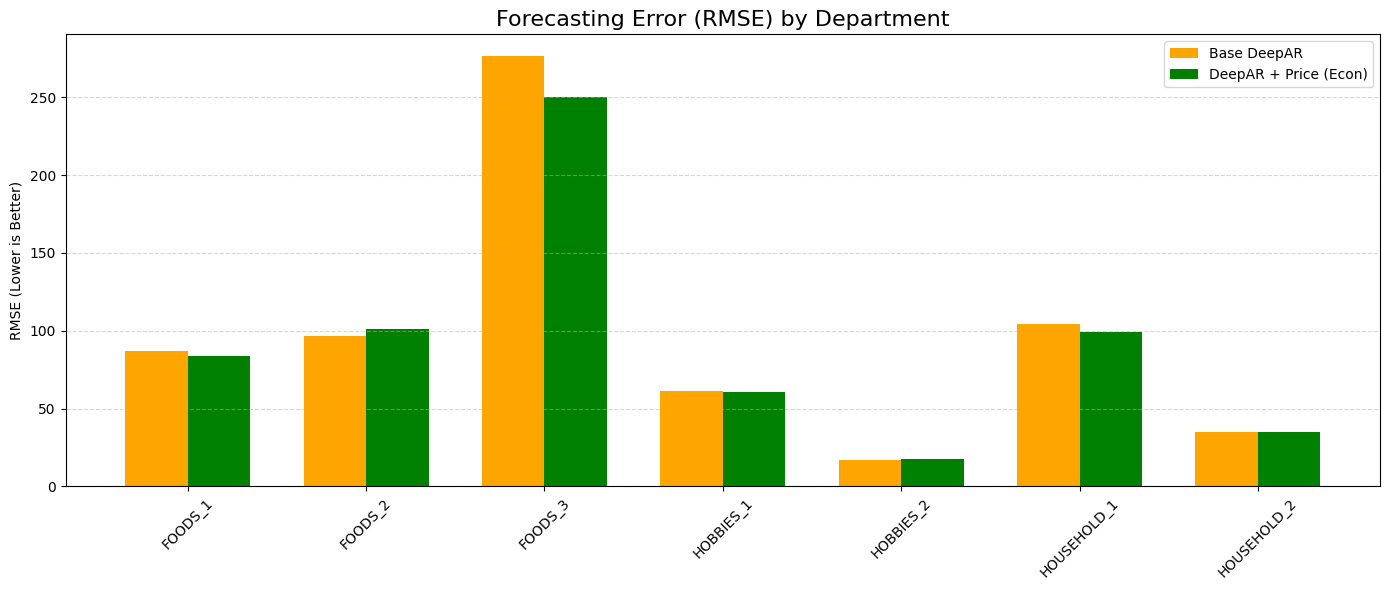

In [31]:
# Gather RMSE metrics
dept_names = list(trained_predictors.keys())
base_rmse_list = []
econ_rmse_list = []
evaluator = Evaluator(quantiles=[0.5])

for dept in dept_names:
    # Base RMSE
    fcst_base, ts_base = make_evaluation_predictions(dataset=test_datasets[dept], predictor=trained_predictors[dept], num_samples=100)
    metrics_base, _ = evaluator(list(ts_base), list(fcst_base))
    base_rmse_list.append(metrics_base['RMSE'])
    
    # Econ RMSE
    fcst_econ, ts_econ = make_evaluation_predictions(dataset=test_econ_datasets[dept], predictor=trained_econ_predictors[dept], num_samples=100)
    metrics_econ, _ = evaluator(list(ts_econ), list(fcst_econ))
    econ_rmse_list.append(metrics_econ['RMSE'])

# Create the Bar Chart
x = np.arange(len(dept_names))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, base_rmse_list, width, label='Base DeepAR', color='orange')
plt.bar(x + width/2, econ_rmse_list, width, label='DeepAR + Price (Econ)', color='green')

plt.ylabel('RMSE (Lower is Better)')
plt.title('Forecasting Error (RMSE) by Department', fontsize=16)
plt.xticks(x, dept_names, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

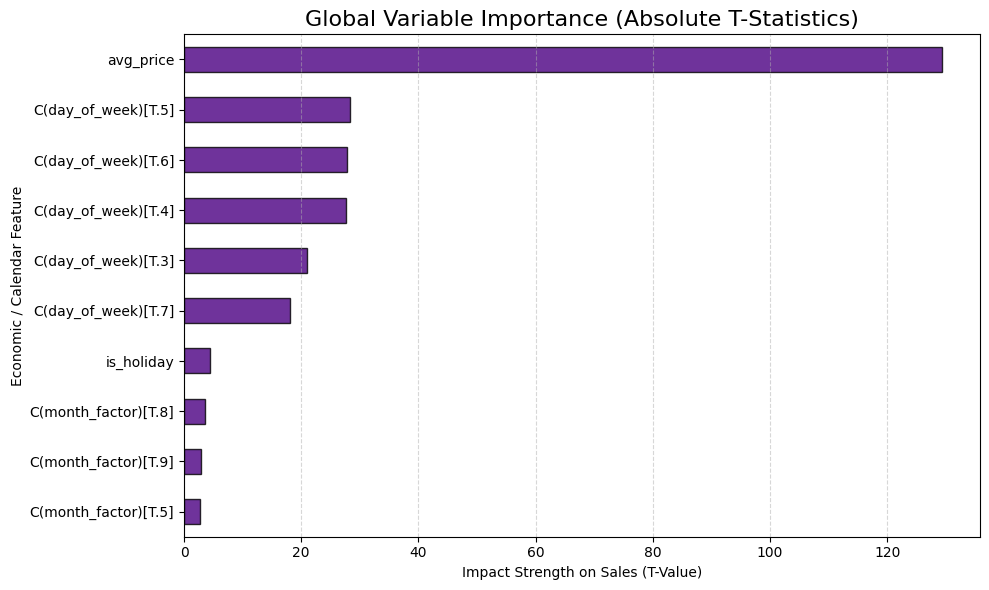

In [32]:
# Extract the absolute t-values from your initial OLS Econometrics model
# This requires 'simple_model' to still be in memory from Cell 11
t_values = simple_model.tvalues.drop('Intercept').abs()

# Sort and get the top 10 most powerful drivers of sales
top_features = t_values.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='indigo', edgecolor='black', alpha=0.8)

plt.title("Global Variable Importance (Absolute T-Statistics)", fontsize=16)
plt.xlabel("Impact Strength on Sales (T-Value)")
plt.ylabel("Economic / Calendar Feature")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Calculating Train vs. Test errors for the Overfitting Graph...


Running evaluation: 10it [00:00, 118.70it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 117.92it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 118.85it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 125.28it/s]
/opt/miniconda3/envs/econ491_walmart_forcas

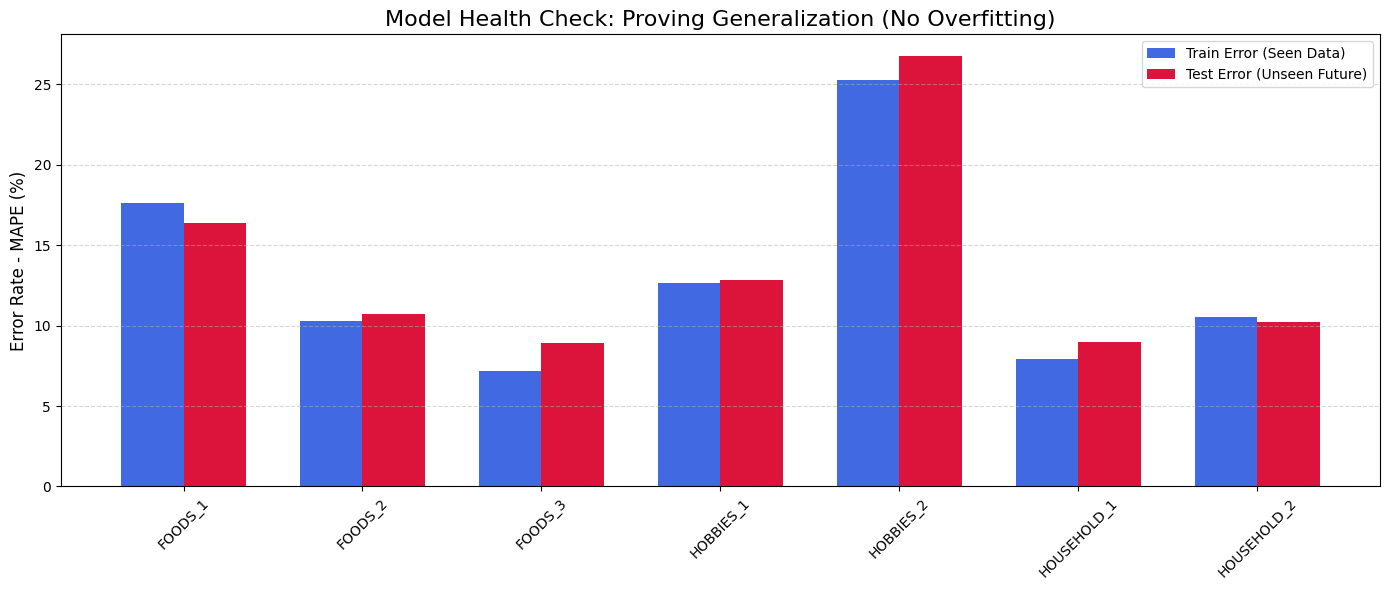

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gluonts.evaluation import Evaluator
from gluonts.dataset.common import ListDataset
from gluonts.evaluation import make_evaluation_predictions

print("Calculating Train vs. Test errors for the Overfitting Graph...")

dept_names = list(trained_econ_predictors.keys())
train_mape_list = []
test_mape_list = []
evaluator = Evaluator(quantiles=[0.5])
split_date = pd.to_datetime("2016-04-24")

# Gather Train and Test metrics for each department
for dept in dept_names:
    # 1. Recreate Train Dataset for this specific department
    dept_ts_data = ts_data.xs(dept, level='dept_id', axis=1)
    train_dept_ts = dept_ts_data[dept_ts_data.index <= split_date]
    
    dept_price_data = price_data.xs(dept, level='dept_id', axis=1)
    train_dept_price = dept_price_data[dept_price_data.index <= split_date]
    
    train_ds_econ = ListDataset(
        [
            {
                "start": train_dept_ts.index[0], 
                "target": train_dept_ts[col].values,
                "feat_dynamic_real": [train_dept_price[col].values]
            } 
            for col in train_dept_ts.columns
        ],
        freq="D"
    )
    
    # 2. Get Train Error
    fcst_train, ts_train = make_evaluation_predictions(dataset=train_ds_econ, predictor=trained_econ_predictors[dept], num_samples=100)
    metrics_train, _ = evaluator(list(ts_train), list(fcst_train))
    train_mape_list.append(metrics_train['MAPE'] * 100)
    
    # 3. Get Test Error (using the unseen test datasets we saved earlier)
    fcst_test, ts_test = make_evaluation_predictions(dataset=test_econ_datasets[dept], predictor=trained_econ_predictors[dept], num_samples=100)
    metrics_test, _ = evaluator(list(ts_test), list(fcst_test))
    test_mape_list.append(metrics_test['MAPE'] * 100)

# --- Draw the Graph ---
x = np.arange(len(dept_names))
width = 0.35

plt.figure(figsize=(14, 6))

# Plot the bars side-by-side
plt.bar(x - width/2, train_mape_list, width, label='Train Error (Seen Data)', color='royalblue')
plt.bar(x + width/2, test_mape_list, width, label='Test Error (Unseen Future)', color='crimson')

plt.ylabel('Error Rate - MAPE (%)', fontsize=12)
plt.title('Model Health Check: Proving Generalization (No Overfitting)', fontsize=16)
plt.xticks(x, dept_names, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("overfitting_bar_chart.png")
plt.show()

In [47]:
# =========================================================
# NEW EXPORT CELL: EXTRACT REAL DEEPAR PREDICTIONS
# =========================================================
import pandas as pd

all_deepar_preds = []

print("Extracting predictions for all departments and stores...")

for dept in trained_econ_predictors.keys():
    # 1. Get the model and the test data for this department
    predictor = trained_econ_predictors[dept]
    test_ds = test_econ_datasets[dept]
    
    # 2. Identify which stores are in this dataset 
    # (In your code, the columns of the pivoted table were the store_ids)
    dept_ts_data = ts_data.xs(dept, level='dept_id', axis=1)
    store_ids = dept_ts_data.columns 
    
    # 3. Generate the raw forecast objects
    forecast_it, _ = make_evaluation_predictions(dataset=test_ds, predictor=predictor, num_samples=100)
    forecasts = list(forecast_it) # This is a list of forecasts, one per store
    
    # 4. Extract the median (0.5 quantile) for every store
    for i, store_id in enumerate(store_ids):
        f = forecasts[i]
        
        # Create a mini dataframe for this specific store
        store_df = pd.DataFrame({
            'date': f.index.to_timestamp(),
            'dept_id': dept,
            'store_id': store_id,
            'pred_deepar': f.quantile(0.5) # This is the REAL model guess
        })
        all_deepar_preds.append(store_df)

# Combine everything into one master forecast dataframe
forecast_df = pd.concat(all_deepar_preds, ignore_index=True)

# 5. Save the REAL predictions to your CSV
forecast_df.to_csv("/Users/conniezhang/Desktop/ECON491/temp_predictions.csv", index=False)

print(f"Done! Exported {len(forecast_df)} rows of REAL predictions.")
print(forecast_df.head())

Extracting predictions for all departments and stores...
Done! Exported 1890 rows of REAL predictions.
        date  dept_id store_id  pred_deepar
0 2016-04-26  FOODS_1     CA_1   253.959717
1 2016-04-27  FOODS_1     CA_1   264.140625
2 2016-04-28  FOODS_1     CA_1   297.631897
3 2016-04-29  FOODS_1     CA_1   345.505737
4 2016-04-30  FOODS_1     CA_1   389.478149
